In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Set your custom directory
os.environ["KAGGLEHUB_CACHE"] = r"data"

import kagglehub

# Download latest version
path = kagglehub.dataset_download("akrambelha/global-e-commerce-dataset-1m-records-20242026")

print("Path to dataset files:", path)
df=pd.read_csv(r"data\datasets\akrambelha\global-e-commerce-dataset-1m-records-20242026\versions\1\ecommerce_dataset_+1m.csv")
df.to_csv(r"data\ecommerce_dataset_+1m.csv")


Path to dataset files: data\datasets\akrambelha\global-e-commerce-dataset-1m-records-20242026\versions\1


In [8]:
df1=pd.read_csv(r"data\datasets\akrambelha\global-e-commerce-dataset-1m-records-20242026\versions\1\ecommerce_dataset_+1m.csv")

In [ ]:
df.columns

Index(['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'return_reason', 'customer_id', 'customer_name',
       'gender', 'age', 'customer_segment', 'country', 'city',
       'customer_loyalty_score', 'total_orders_by_customer',
       'account_creation_date', 'product_id', 'product_name', 'category',
       'sub_category', 'brand', 'product_rating_avg', 'product_reviews_count',
       'stock_quantity', 'unit_price_usd', 'quantity', 'discount_percent',
       'discount_amount_usd', 'total_price_usd', 'cost_usd', 'profit_usd',
       'tax_usd', 'currency', 'payment_method', 'payment_status',
       'installment_plan', 'shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status', 'rating', 'review_sentiment', 'customer_feedback',
       'coupon_used', 'coupon_code', 'campaign_source', 'device_type',
       'traf

In [ ]:
temp=['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name',
       'gender', 'age', 'customer_segment', 'country', 'city',
       'customer_loyalty_score', 'total_orders_by_customer',
       'account_creation_date',]
len(temp)

20

In [ ]:
assigned_cols=['order_id','order_date','order_status','order_priority','is_weekend',
               'customer_id','customer_name','gender','age','customer_segment',
               'country','city','customer_loyalty_score','total_orders_by_customer',
               'account_creation_date']

In [ ]:
df=df[assigned_cols]

In [ ]:
df.head()

,order_id,order_date,order_status,order_priority,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
0,ORD-XAJI0,2024-10-14 11:20:05.496679,Completed,Medium,No,CUS-6DPBH,Drew Warren,Male,53,Regular,Netherlands,Utrecht,22.0,38,2022-04-23
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,Completed,Low,No,CUS-G0FN9,Victor Sullivan,Male,61,Regular,United States,Los Angeles,82.2,21,2022-08-22
2,ORD-YTJXE,2025-03-17 19:49:36.983317,Completed,High,No,CUS-Q85JS,Jason Garcia,Male,50,VIP,France,Nice,60.9,10,2024-08-04
3,ORD-EIMVI,2024-09-27 06:24:44.913768,Completed,Low,No,CUS-CWI64,David Norris,Male,50,Regular,Italy,Milan,53.9,47,2023-08-06
4,ORD-OR56F,2025-05-21 17:10:48.401882,Completed,High,No,CUS-O72KZ,Laura Phillips,Female,27,Regular,Germany,Berlin,57.9,35,2023-01-02


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 15 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_id                  1000123 non-null  object 
 1   order_date                1000123 non-null  object 
 2   order_status              1000123 non-null  object 
 3   order_priority            1000123 non-null  object 
 4   is_weekend                1000123 non-null  object 
 5   customer_id               1000123 non-null  object 
 6   customer_name             1000123 non-null  object 
 7   gender                    1000123 non-null  object 
 8   age                       1000123 non-null  int64  
 9   customer_segment          1000123 non-null  object 
 10  country                   1000123 non-null  object 
 11  city                      1000123 non-null  object 
 12  customer_loyalty_score    1000123 non-null  float64
 13  total_orders_by_customer  1

In [ ]:
df.loc[df['order_id'].duplicated(False)].sort_values(by='order_id').head(10)

,order_id,order_date,order_status,order_priority,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
726923,ORD-008WV,2025-02-08 05:49:03.813844,Completed,Medium,Yes,CUS-1L9BQ,Michael Butler,Male,44,Regular,Canada,Toronto,88.0,48,2024-07-30
958078,ORD-008WV,2024-12-07 17:00:22.429434,Completed,Low,Yes,CUS-EJGVX,Michelle Duncan,Female,60,Regular,Germany,Cologne,33.7,11,2024-11-26
881574,ORD-00B89,2025-04-21 03:30:09.548645,Completed,Low,No,CUS-34FSG,Sarah Miller,Female,57,Premium,United Kingdom,London,72.4,35,2024-08-05
611006,ORD-00B89,2024-12-03 19:12:49.590163,Completed,Medium,No,CUS-9IPMP,Jessica Hicks,Female,33,VIP,Spain,Bilbao,51.1,33,2021-07-03
681574,ORD-00EJ3,2024-04-28 06:40:37.901501,Pending,Low,Yes,CUS-C9DUH,Donald Taylor,Male,34,VIP,Belgium,Antwerp,83.1,16,2021-04-04
436647,ORD-00EJ3,2025-10-29 18:19:15.111634,Completed,Low,No,CUS-JMM2A,Amanda Johnson,Female,24,Premium,Australia,Perth,63.5,11,2021-05-01
490595,ORD-00HSS,2024-07-06 18:00:45.884511,Returned,Low,Yes,CUS-14AE3,Jeffery Farmer,Male,73,Regular,Spain,Barcelona,47.1,30,2024-01-17
211839,ORD-00HSS,2024-09-22 20:39:19.783901,Returned,Medium,Yes,CUS-S2081,Ashley Diaz,Female,18,Premium,Australia,Sydney,16.3,38,2021-03-11
986724,ORD-00LF5,2025-03-15 03:09:00.809135,Completed,High,Yes,CUS-8VSXN,Carl Lane,Male,48,Regular,Germany,Hamburg,72.9,35,2023-03-25
766113,ORD-00LF5,2025-04-22 19:18:31.394438,Completed,Medium,No,CUS-TJB0L,Chelsea King,Female,63,Premium,Belgium,Bruges,53.0,36,2024-01-07


In [ ]:
df.loc[df['customer_id'].duplicated(False)].sort_values(by='customer_id').head(10)

,order_id,order_date,order_status,order_priority,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
822633,ORD-EY7WH,2024-09-24 13:48:25.474149,Completed,Low,No,CUS-002ZC,Gregory Parker,Male,40,Regular,Italy,Rome,79.8,3,2022-08-06
217577,ORD-TP5RH,2024-12-27 13:43:23.168144,Completed,Medium,No,CUS-002ZC,Darius Rodriguez,Male,68,Regular,Germany,Cologne,27.0,11,2024-05-05
244484,ORD-6ZH6R,2025-11-15 02:59:35.561786,Completed,Low,Yes,CUS-00C5B,Mary Alexander,Female,61,Regular,Belgium,Ghent,70.8,15,2021-07-07
563921,ORD-RU7JB,2024-11-29 02:46:51.718406,Pending,Medium,No,CUS-00C5B,Christopher Kim,Male,27,Regular,Germany,Berlin,59.3,25,2023-02-17
396576,ORD-5O2W2,2025-03-01 16:19:30.457870,Pending,High,Yes,CUS-0131E,Vanessa Collins,Female,69,Premium,Belgium,Brussels,11.7,2,2022-05-22
359686,ORD-W47RC,2025-10-07 03:14:40.950769,Completed,Medium,No,CUS-0131E,Isaac Norman,Male,26,Premium,Canada,Toronto,42.7,5,2023-01-16
951061,ORD-LM5EA,2025-11-23 04:55:59.852062,Returned,Medium,Yes,CUS-01518,William Howard,Male,33,VIP,United States,Chicago,2.5,12,2023-02-13
663900,ORD-F23XG,2026-01-04 12:38:19.337625,Returned,High,Yes,CUS-01518,Ariana Yu,Female,66,Regular,Spain,Seville,95.4,4,2025-04-13
66512,ORD-LIIMK,2025-03-12 00:46:47.213034,Completed,Medium,No,CUS-016UA,Emily Smith,Female,66,VIP,Australia,Melbourne,90.9,45,2024-07-25
235917,ORD-EN728,2025-05-15 19:56:47.669096,Completed,Medium,No,CUS-016UA,Brittany Frederick,Female,39,Regular,Belgium,Antwerp,64.9,13,2022-07-24


In [ ]:
df['customer_name'].nunique()

330156

In [ ]:
df[['customer_id','customer_name']].groupby('customer_name').count()

,customer_id
customer_name,
Aaron Abbott,4
Aaron Acevedo,2
Aaron Acosta,1
Aaron Acosta MD,1
Aaron Adams,12
...,...
Zoe Wilson,4
Zoe Winters,1
Zoe Wright,2


In [ ]:
df[df['customer_name']=='Aaron Adams']

,order_id,order_date,order_status,order_priority,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
56257,ORD-DJGZM,2025-02-02 13:16:32.666007,Completed,Medium,Yes,CUS-7VHQ9,Aaron Adams,Male,37,Premium,United Kingdom,Leeds,90.6,44,2023-06-30
111915,ORD-ZB5X0,2025-04-14 06:55:58.424017,Pending,High,No,CUS-H7L6V,Aaron Adams,Male,42,Premium,Germany,Hamburg,67.0,11,2023-09-27
276981,ORD-F4WWJ,2025-11-09 01:50:29.427604,Pending,High,Yes,CUS-NKN1W,Aaron Adams,Male,34,Regular,Canada,Vancouver,1.1,39,2025-02-04
301828,ORD-39DC3,2025-10-19 13:49:11.883083,Cancelled,Low,Yes,CUS-25O3U,Aaron Adams,Male,21,Premium,United Kingdom,Manchester,86.2,30,2025-05-11
309763,ORD-C4C2K,2025-07-04 08:21:59.356142,Returned,Medium,No,CUS-QCYQO,Aaron Adams,Male,31,Regular,Australia,Sydney,12.3,29,2021-05-07
396789,ORD-Z0EOC,2024-08-22 15:10:46.724032,Completed,Low,No,CUS-O8A9B,Aaron Adams,Male,27,Regular,Spain,Barcelona,90.0,12,2023-03-30
632688,ORD-XRCDQ,2025-03-02 23:05:11.418470,Completed,High,Yes,CUS-H66EV,Aaron Adams,Male,40,Regular,France,Marseille,68.6,28,2022-03-26
670733,ORD-9R4H3,2025-07-24 04:34:40.718323,Completed,Medium,No,CUS-NPF8I,Aaron Adams,Male,33,Premium,Canada,Calgary,8.8,23,2025-02-16
756344,ORD-PMWP8,2026-01-26 01:35:14.251919,Completed,Low,No,CUS-725O6,Aaron Adams,Male,31,Regular,Italy,Naples,56.2,48,2022-10-19
775557,ORD-JKMU2,2025-09-19 19:40:28.115672,Cancelled,Low,No,CUS-4KTQS,Aaron Adams,Male,47,Regular,France,Marseille,63.5,27,2022-02-09


In [ ]:
df.shape[0]

1000123

In [ ]:
df['order_date']=pd.to_datetime(df['order_date'])

In [ ]:
df['order_status'].unique()

array(['Completed', 'Returned', 'Pending', 'Cancelled', 'Processing'],
      dtype=object)

<Axes: xlabel='order_status'>

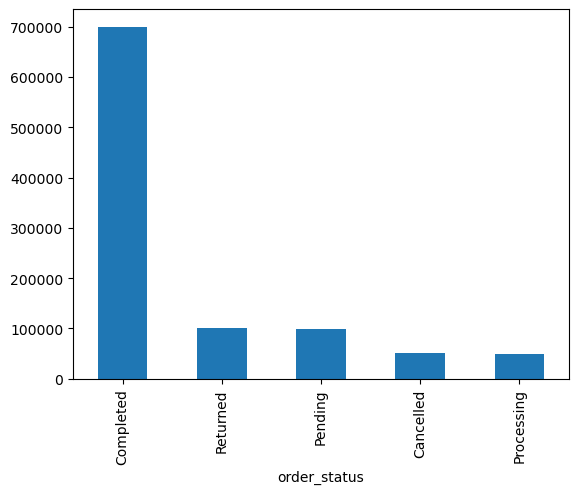

In [ ]:
df['order_status'].value_counts().plot(kind='bar')

In [ ]:
df['order_priority'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

[Text(0, 3, '333899'), Text(0, 3, '333716'), Text(0, 3, '332508')]

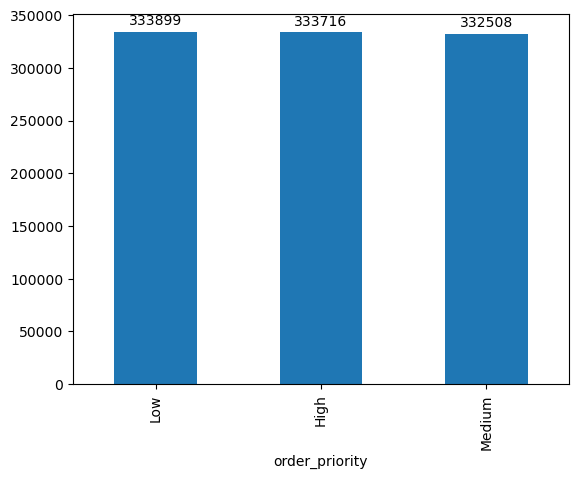

In [ ]:
ax=df['order_priority'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)

In [ ]:
df['is_weekend'].unique()

array(['No', 'Yes'], dtype=object)

[Text(0, 3, '713021'), Text(0, 3, '287102')]

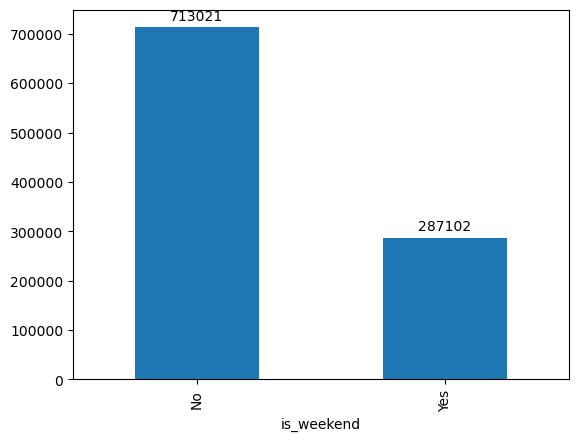

In [ ]:
ax=df['is_weekend'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)

In [ ]:
df['customer_name'].nunique()

330156

In [ ]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

[Text(0, 3, '500180'), Text(0, 3, '499943')]

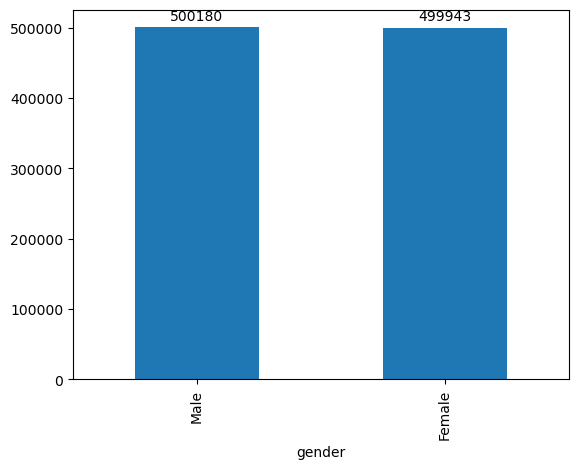

In [ ]:
ax=df['gender'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)

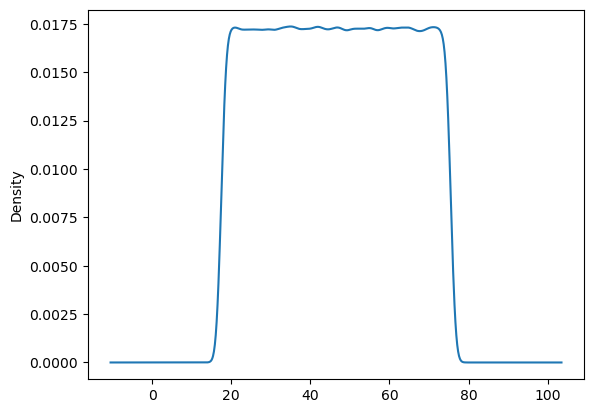

In [ ]:
df['age'].plot(kind='kde')
plt.show()

In [ ]:
df['customer_segment'].unique()

array(['Regular', 'VIP', 'Premium'], dtype=object)

<Axes: xlabel='customer_segment'>

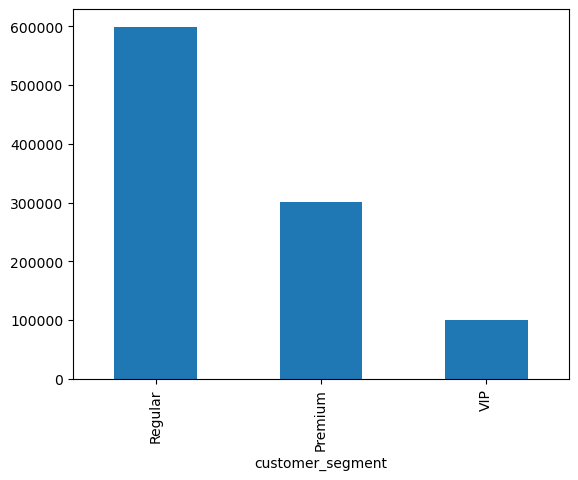

In [ ]:
df['customer_segment'].value_counts().plot(kind='bar')

In [ ]:
df['country'].unique()

array(['Netherlands', 'United States', 'France', 'Italy', 'Germany',
       'Canada', 'Australia', 'Belgium', 'United Kingdom', 'Spain'],
      dtype=object)

[Text(0, 0, '100548'),
 Text(0, 0, '100357'),
 Text(0, 0, '100147'),
 Text(0, 0, '100064'),
 Text(0, 0, '100041'),
 Text(0, 0, '100023'),
 Text(0, 0, '99774'),
 Text(0, 0, '99761'),
 Text(0, 0, '99742'),
 Text(0, 0, '99666')]

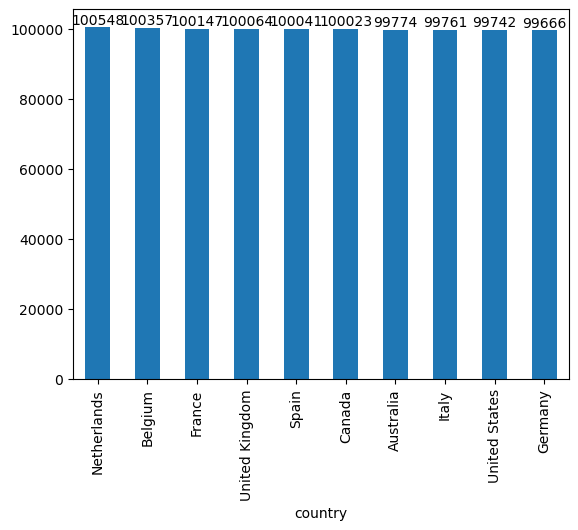

In [ ]:
ax=df['country'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])

In [ ]:
df['city'].nunique()

50

<Axes: xlabel='city'>

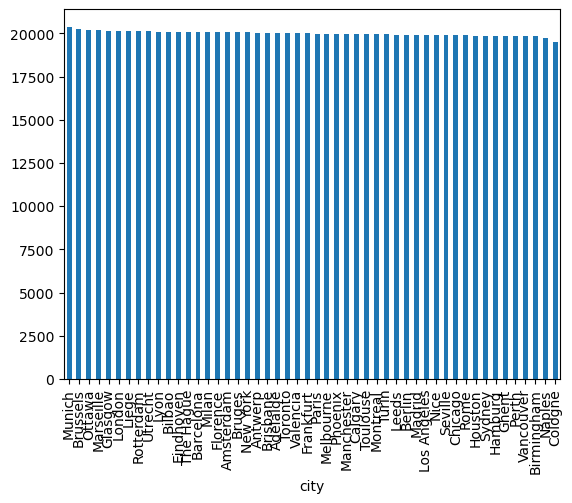

In [ ]:
df['city'].value_counts().plot(kind='bar')

In [ ]:
df['customer_loyalty_score'].describe()

count    1.000123e+06
mean     4.997252e+01
std      2.889377e+01
min      0.000000e+00
25%      2.490000e+01
50%      5.000000e+01
75%      7.500000e+01
max      1.000000e+02
Name: customer_loyalty_score, dtype: float64

<Axes: ylabel='Density'>

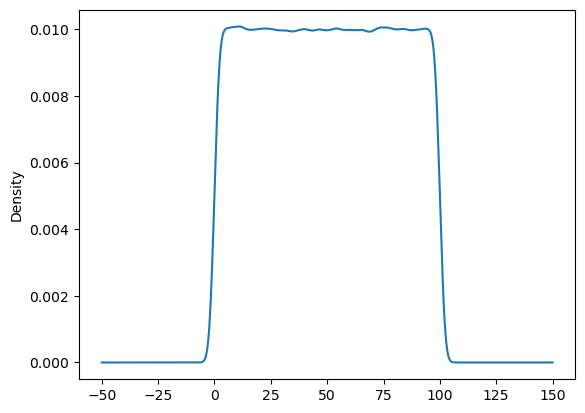

In [ ]:
df['customer_loyalty_score'].plot(kind='kde')

In [ ]:
df['total_orders_by_customer'].describe()

count    1.000123e+06
mean     2.548700e+01
std      1.443421e+01
min      1.000000e+00
25%      1.300000e+01
50%      2.500000e+01
75%      3.800000e+01
max      5.000000e+01
Name: total_orders_by_customer, dtype: float64

<Axes: ylabel='Density'>

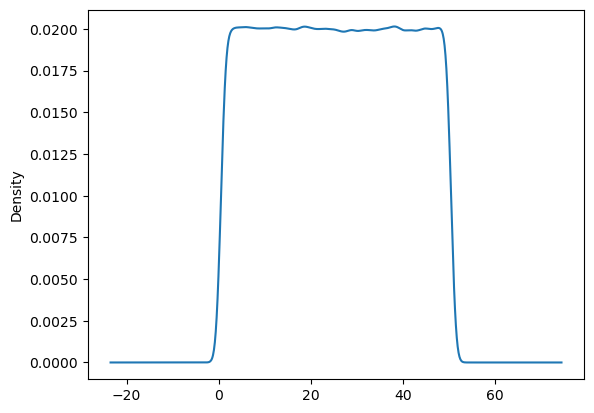

In [ ]:
df['total_orders_by_customer'].plot(kind='kde')

In [ ]:
df['account_creation_date'].nunique()

1826

In [ ]:
df['account_creation_date']=pd.to_datetime(df['account_creation_date'])

<Axes: xlabel='order_date'>

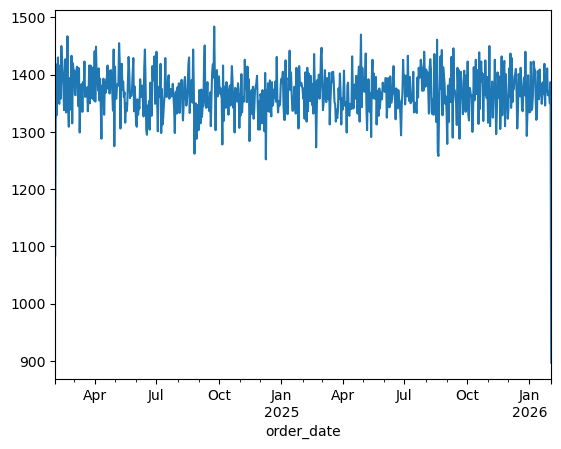

In [ ]:
order_counts = df.groupby(df['order_date'].dt.to_period("D")).size()

order_counts.plot(kind='line')

In [ ]:
df[['customer_id','customer_name']].groupby('customer_id').count()['customer_name'].unique()

array([1, 2, 3])

In [ ]:
df[['order_id','order_date']].groupby('order_id').count()['order_date'].unique()

array([1, 2, 3])

In [ ]:
df1['product_id'] = pd.factorize(df1['product_name'])[0] + 1

In [ ]:
df1['order_id'] = df1['order_id'].astype(str) + '' + df1.groupby('order_id').cumcount().astype(str)

In [ ]:
df1 = df1['customer_id'].astype(str) + '' + df1.groupby('customer_id')['customer_name'].transform(lambda x: pd.factorize(x)[0]).astype(str)

In [ ]:
temp.nunique()

1000122

In [ ]:
df1['order_id'].nunique()

1000123